# Fig 7b — E7 delivered goodput (filtered + aligned, zero filter delay)

Companion to Fig 7. Same 9×3 grid, but the heat value is the *delivered
goodput* (kbps of unique new media the link actually carried) rather than
the *selected quality* the ABR requested. Mirrors Fig 5b for the
zero-delay filtered + aligned client (see _data.compute_delivered_goodput_kbps).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.pyplot as plt
import numpy as np

from _data import (
    E6_COL_ORDER,
    E6_ROW_ORDER,
    e7_delivered_goodput_matrix,
)
from _style import TEXT_WIDTH_IN, apply_acm_style

apply_acm_style()

In [2]:
goodput_matrix = e7_delivered_goodput_matrix()

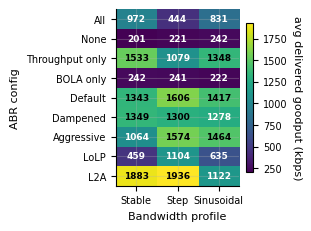

In [3]:
PROFILE_DISPLAY = {
    "stable1.5M":  "Stable",
    "step3M_500k": "Step",
    "sin600k_3M":  "Sinusoidal",
}
CONFIG_DISPLAY = {
    "none":            "None",
    "all":             "All",
    "throughput-only": "Throughput only",
    "bola-only":       "BOLA only",
    "default":         "Default",
    "dampened":        "Dampened",
    "aggressive":      "Aggressive",
    "lolp":            "LoLP",
    "l2a":             "L2A",
}

fig, ax = plt.subplots(figsize=(3.0, 2.2), constrained_layout=True)

masked = np.ma.masked_invalid(goodput_matrix.values)
im = ax.imshow(masked, cmap="viridis", aspect="auto",
               interpolation="nearest", origin="upper")
ax.set_xticks(range(len(E6_COL_ORDER)))
ax.set_xticklabels(
    [PROFILE_DISPLAY.get(p, p).split("\n")[0] for p in E6_COL_ORDER],
    rotation=0, ha="center", fontsize=7,
)
ax.set_yticks(range(len(E6_ROW_ORDER)))
ax.set_yticklabels(
    [CONFIG_DISPLAY.get(c, c) for c in E6_ROW_ORDER],
    fontsize=7,
)
ax.set_xlabel("Bandwidth profile")
ax.set_ylabel("ABR config")

for i, row in enumerate(E6_ROW_ORDER):
    for j, col in enumerate(E6_COL_ORDER):
        goodput = goodput_matrix.iloc[i, j]
        if np.isnan(goodput):
            ax.text(j, i, "—", ha="center", va="center", color="#999999", fontsize=7)
            continue
        rgba = im.cmap(im.norm(goodput))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "white" if luminance < 0.5 else "black"
        ax.text(j, i, f"{goodput:.0f}", ha="center", va="center",
                color=text_color, fontsize=6.5, weight="bold")

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label("avg delivered goodput (kbps)", rotation=270, labelpad=10)

In [4]:
fig.savefig(Path.cwd().parent / "figures" / "fig7b_e7_goodput.pdf")
fig.savefig(Path.cwd().parent / "figures" / "fig7b_e7_goodput.png", dpi=200)